<a href="https://colab.research.google.com/github/Ellenkyei/Classification-and-Regression/blob/main/5_000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**K-NEAREST NEIGHBOR (KNN)**


In [ ]:
#Importing Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score, confusion_matrix


In [ ]:
#loading the dataset
dataset = pd.read_csv(r'/content/sample_data/StudentPerformanceFactors.csv')


In [ ]:
#Creating my dependent variable
dataset['outcome'] = dataset['Exam_Score'].apply(lambda score: 'PASS' if score >=70 else 'FAIL' )

In [ ]:
dataset.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,outcome
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67,FAIL
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61,FAIL
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,PASS
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71,PASS
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70,PASS


In [ ]:
#defining my variables
x = dataset.iloc[ : , 0:2].values
y = dataset.iloc[ : , -1].values

In [ ]:
#spliting my dataset into training and testing

x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=100, test_size=0.2)

In [ ]:
#developing the knn model
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
#using the model to  prediction
knn.predict([[23,64]])

array(['FAIL'], dtype=object)

In [ ]:
# Using it on our testing data
y_predict = knn.predict(x_test)

**MODEL EVALUATION**

We will make use of these classification metrics in sklearn:

1. Accuracy
2. Precision
3. F1_score
4. Confusion matrix
5. ROC curve

In [ ]:
#Accuracy
Acc = accuracy_score(y_test,y_predict)

print (f'The Accuracy score of this model is:  {Acc :.2f}')

The Accuracy score of this model is:  0.84


In [ ]:
#PRECISION
#precision = precision_score(y_test, y_predict, pos_label='PASS')

precision = precision_score(y_test, y_predict, average='weighted')

print (f'The Precision Score for This Model is {precision :.2f}')

The Precision Score for This Model is 0.84


In [ ]:
#F1_SCORE
#F1_score = f1_score(y_test, y_predict, pos_label='PASS')
F1_score = f1_score(y_test, y_predict, average='weighted')

print (f'The F1_score For This Model is {F1_score:.2f}')


The F1_score For This Model is 0.84


In [ ]:
#RECALL
#Recall = recall_score(y_test, y_predict, pos_label='PASS')
Recall = recall_score(y_test, y_predict, average='weighted')

print (f'The Recall Value For This Model is {Recall:.2f}')

The Recall Value For This Model is 0.84


The Confusion Matrix For This Model is [[910  89]
 [122 201]]


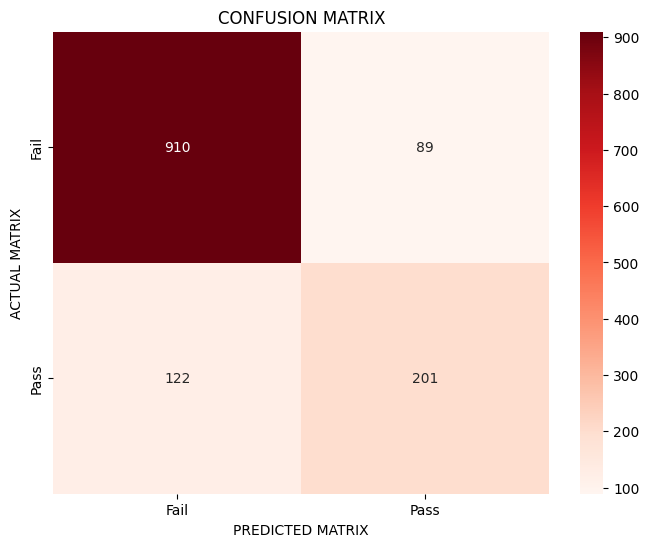

In [ ]:
#Confusion Matrix
confusion = confusion_matrix(y_test, y_predict)
print (f'The Confusion Matrix For This Model is {confusion}')

#ploting the confusion matrix to visualize
plt.figure(figsize=(8,6))
sns.heatmap(confusion, annot=True, cmap='Reds', fmt = 'd' , xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('CONFUSION MATRIX')
plt.xlabel('PREDICTED MATRIX')
plt.ylabel('ACTUAL MATRIX')
plt.show()

In [ ]:
#ROC CURVE ANALYSIS
